# Synthetic threshold validation — analysis

Notebook companion to [`synthetic_threshold_validator.py`](./synthetic_threshold_validator.py). It loads per-variant **image attributes** and **gate flags** from `results/synthetic_validation/variant_attributes.csv` (produced by the script), then visualizes and analyzes them. This notebook does not regenerate images unless you run the optional Ollama cell.

## How this notebook is organized

**Part 1 — Synthetic validation (attribute + threshold behavior)**

1. **Load data** — `variant_attributes.csv`, normalize gate booleans, build **`df_test`** = subset of rows used for the **aggregated** checks below (see [Test scope](#Test-scope-environment)).
2. **Four-rule thresholds** — same constants as the pre-screener: entropy, aspect, `white_region_ratio` (min coverage), and rotation: **>50° retake** (hard), **25–50°** soft message only, **<25°** OK; “first crossing” while sweeping parameters.
3. **Family sweeps (plots)** — one section per failure mode: distance/clutter, rotation, crop (bottom + left), Gaussian + motion blur; optional gate mix table and on-disk `summary.md` / `false_positive_report.txt` / `base_gate_check.txt` text.

**Part 2 — Pipeline and performance validation**

4. **`real_photo_characterizer` API** — re-`extract_attributes` on a file vs CSV; `analyze` + `find_best_threshold` with synthetic pass/fail labels (`pass` = no four-rule gate).
5. **D01 LLM (optional)** — same `run_extraction` path as a full characterizer run; gated by `SYNTHETIC_LLM_MAX` and related env vars; can write `synthetic_eval_runs.csv`.
6. **Stats (blur_testing-style)** — same as above: metrics from **`df_test`** only.

Run **Part 1** cells top-to-bottom; **Part 2** is optional and may require a local Ollama server for the LLM step.

## Test scope (environment)

Plot cells in **Part 1** always read the full `df` (all families in the CSV). For **gate mix**, **Part 2** (API / LLM / stats), the notebook uses **`df_test`**:

- Default: **`df_test` = all rows** (same as `df`).
- To limit which **families of variants** are included, set **`SYNTHETIC_FAMILIES`** (or alias **`SYNTHETIC_TEST_FAMILIES`**) to a comma-separated list before running the first code cell, e.g. `export SYNTHETIC_FAMILIES=blur,rotation` or `crop,distance`.
- **Coarse names** expand to the validator’s `family` values: `distance` → `distance`; `rotation` → `rotation`; `crop` → `crop_bottom`, `crop_left`; `blur` → `blur_gaussian`, `blur_motion`. You can also list **exact** names: `blur_gaussian`, `crop_left`, etc.
- `SYNTHETIC_FAMILIES=all` (or unset) means no filter. Unknown tokens are ignored with a warning. If the filter leaves **fewer than 2** rows, the stats cells will error — widen the list or use `all`.
- If `df_test` is missing (e.g. you jumped to Part 2 without re-running the load cell), downstream cells set **`df_test = df`** (all families). Re-run the first code cell to apply `SYNTHETIC_FAMILIES` again.

LLM run limits (e.g. `SYNTHETIC_LLM_MAX`) apply **within** `df_test` (see the LLM cell).

## Regenerate variant images and CSV

From the repo root or from `research/eval` (see script `--help`):
```bash
python research/eval/synthetic_threshold_validator.py \
  --base spike/artifacts/clean/jpeg/D01-clean.jpg \
  --out research/eval/results/synthetic_validation \
  --families all
```


In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

# Run this notebook with cwd = repo root, or with cwd = `research/eval` (Jupyter "Open folder" that dir).
_cands = [Path("research/eval"), Path(".")]
_EV = next((p.resolve() for p in _cands if (p / "synthetic_threshold_validator.py").is_file()), None)
if _EV is None:
    raise FileNotFoundError(
        "Set working directory to repo root or research/eval so synthetic_threshold_validator.py is found"
    )
RESULT = _EV / "results" / "synthetic_validation"
CSV = RESULT / "variant_attributes.csv"
if not CSV.is_file():
    raise FileNotFoundError(f"Missing {CSV}. Run: python research/eval/synthetic_threshold_validator.py --out {RESULT} --families all")

df = pd.read_csv(CSV)
gate_cols = [
    c
    for c in (
        "gate_entropy",
        "gate_rotation",
        "gate_aspect",
        "gate_white",
        "rotation_soft_warning",
    )
    if c in df.columns
]
for c in gate_cols + ["any_gate"]:
    if c in df.columns:
        df[c] = df[c].map(lambda x: str(x).lower() in ("true", "1"))
# --- test scope: which variant *families* feed gate-mix + Part 2 (see intro)
# Env: SYNTHETIC_FAMILIES or SYNTHETIC_TEST_FAMILIES
# Comma list: distance, rotation, crop, blur (coarse) or exact: crop_bottom, blur_motion, …
# Default "all" = no filter. Part 1 plots use the full `df` from the CSV.
import os as _os

def _parse_synthetic_families_env() -> set[str] | None:
    raw = _os.environ.get(
        "SYNTHETIC_FAMILIES", _os.environ.get("SYNTHETIC_TEST_FAMILIES", "all")
    ).strip()
    if not raw or raw.lower() == "all":
        return None
    parts = {t.strip().lower() for t in raw.replace(";", ",").split(",") if t.strip()}
    if not parts:
        return None
    expand: dict[str, list[str]] = {
        "distance": ["distance"],
        "rotation": ["rotation"],
        "crop": ["crop_bottom", "crop_left"],
        "blur": ["blur_gaussian", "blur_motion"],
    }
    exact = {
        "distance",
        "rotation",
        "crop_bottom",
        "crop_left",
        "blur_gaussian",
        "blur_motion",
    }
    out: set[str] = set()
    bad: list[str] = []
    for t in parts:
        if t in expand:
            out.update(expand[t])
        elif t in exact:
            out.add(t)
        else:
            bad.append(t)
    if bad:
        print("SYNTHETIC_FAMILIES: unknown token(s) ignored:", bad)
    if not out:
        print("SYNTHETIC_FAMILIES: no valid tokens; using all families.")
        return None
    return out

_family_scope = _parse_synthetic_families_env()
if _family_scope is None:
    df_test = df
    print(
        "Test scope (gate-mix + Part 2): all families. "
        "Set SYNTHETIC_FAMILIES=blur,rotation to limit."
    )
else:
    _miss = _family_scope - set(df["family"].unique())
    if _miss:
        print("Note: not present in this CSV:", sorted(_miss))
    df_test = df[df["family"].isin(_family_scope)].copy()
    if len(df_test) == 0:
        raise ValueError(
            "SYNTHETIC_FAMILIES selected zero rows. Check names against df['family']."
        )
    print(
        "Test scope (gate-mix + Part 2):",
        sorted(_family_scope),
        "->",
        len(df_test),
        "row(s).",
    )

print(f"Loaded {len(df)} rows from {CSV} (eval dir: {_EV})")
df["family"].value_counts()


Test scope (gate-mix + Part 2): all families. Set SYNTHETIC_FAMILIES=blur,rotation to limit.
Loaded 101 rows from /Users/danfinkel/github/civics/research/eval/results/synthetic_validation/variant_attributes.csv (eval dir: /Users/danfinkel/github/civics/research/eval)


family
distance         27
rotation         24
blur_motion      21
crop_bottom      10
blur_gaussian    10
crop_left         9
Name: count, dtype: int64

## Four-rule detector thresholds (pre-screen)
Same constants as the validator script.

In [2]:
THR_ENTROPY = 5.15
THR_ROTATION_SOFT = 25.0
THR_ROTATION_RETAKE = 50.0
THR_ASPECT = 0.74
THR_WHITE = 0.13


def first_crossing(
    d: pd.DataFrame,
    param: str,
    gate: str,
    *,
    order: str = "desc",
) -> float | None:
    """First row where `gate` is True when scanning `param` (default: high→low)."""
    asc = order == "asc"
    s = d.sort_values(param, ascending=asc)
    hit = s[s[gate] == True]  # noqa: E712
    if hit.empty:
        return None
    return float(hit.iloc[0][param])

## Family 1 — distance / clutter (`histogram_entropy`, `white_region_ratio`)
Document scale vs entropy (clutter) and white ratio (document size in frame).

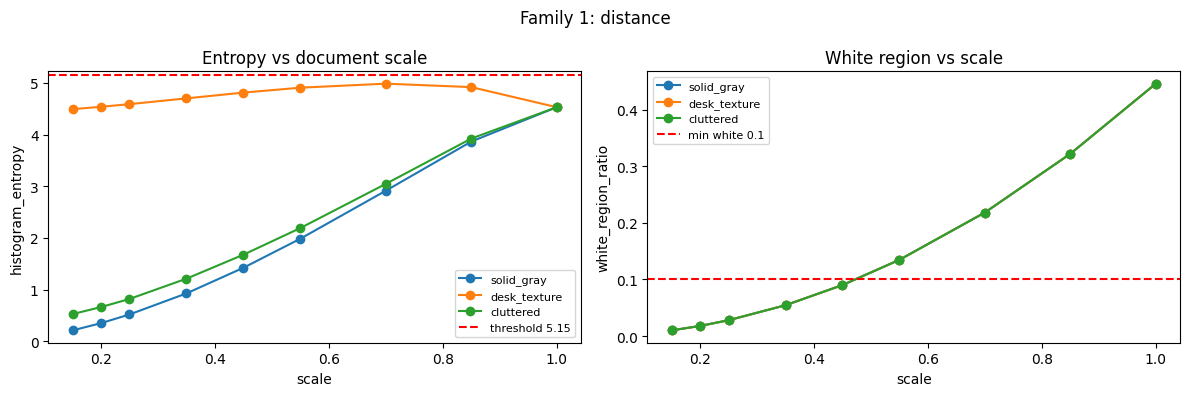

,background,first_entropy@,first_white@
0,solid_gray,None,0.45
1,desk_texture,None,0.45
2,cluttered,None,0.45


In [3]:
D = df[df["family"] == "distance"].copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for bg in D["background"].dropna().unique():
    sub = D[D["background"] == bg].sort_values("scale", ascending=False)
    axes[0].plot(sub["scale"], sub["histogram_entropy"], "o-", label=bg)
    axes[1].plot(sub["scale"], sub["white_region_ratio"], "o-", label=bg)
axes[0].axhline(THR_ENTROPY, color="r", ls="--", label=f"threshold {THR_ENTROPY}")
axes[0].set_xlabel("scale")
axes[0].set_ylabel("histogram_entropy")
axes[0].legend(fontsize=8)
axes[0].set_title("Entropy vs document scale")
axes[1].axhline(THR_WHITE, color="r", ls="--", label=f"min white {THR_WHITE}")
axes[1].set_xlabel("scale")
axes[1].set_ylabel("white_region_ratio")
axes[1].legend(fontsize=8)
axes[1].set_title("White region vs scale")
fig.suptitle("Family 1: distance")
fig.tight_layout()
plt.show()

rows = []
for bg in D["background"].dropna().unique():
    sub = D[D["background"] == bg]
    rows.append(
        {
            "background": bg,
            "first_entropy@": first_crossing(sub, "scale", "gate_entropy", order="desc"),
            "first_white@": first_crossing(sub, "scale", "gate_white", order="desc"),
        }
    )
pd.DataFrame(rows)

## Family 2 — rotation (`|rotation_angle| > 25°`)
Compare applied angle to Hough `rotation_angle`.

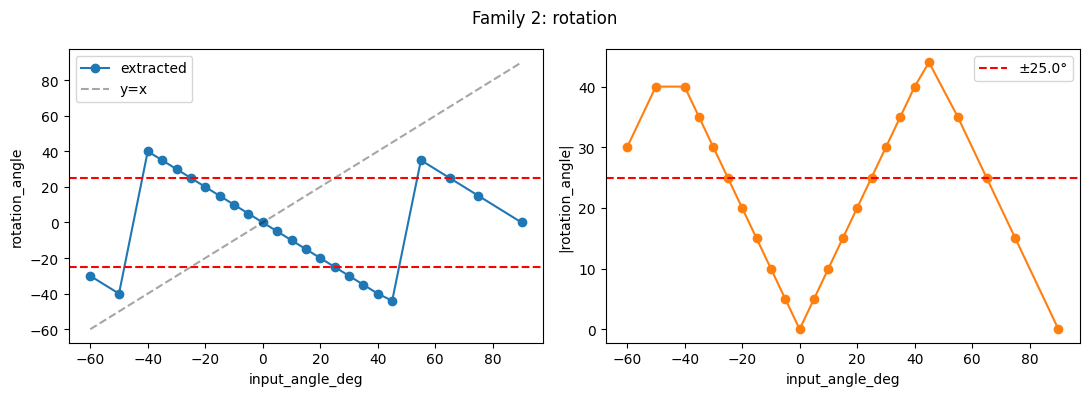

First gate_rotation when sweeping |input| (°): -30.0


,input_angle_deg,rotation_angle,gate_rotation
27,-60.0,-30.000000,True
28,-50.0,-40.000004,True
29,-40.0,40.000000,True
30,-35.0,34.999992,True
31,-30.0,30.000000,True
32,-25.0,25.000000,False
33,-20.0,19.999992,False
34,-15.0,14.999992,False
35,-10.0,9.999992,False
36,-5.0,5.000000,False


In [4]:
R = df[df["family"] == "rotation"].copy().sort_values("input_angle_deg")
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(R["input_angle_deg"], R["rotation_angle"], "o-", label="extracted")
axes[0].plot(R["input_angle_deg"], R["input_angle_deg"], "k--", alpha=0.35, label="y=x")
axes[0].axhline(THR_ROTATION_RETAKE, color="r", ls="--", label="retake (|angle|>50°)")
axes[0].axhline(-THR_ROTATION_RETAKE, color="r", ls="--")
axes[0].axhline(THR_ROTATION_SOFT, color="darkorange", ls=":", label="soft band (25–50°)")
axes[0].axhline(-THR_ROTATION_SOFT, color="darkorange", ls=":")
axes[0].set_xlabel("input_angle_deg")
axes[0].set_ylabel("rotation_angle")
axes[0].legend()
axes[1].plot(R["input_angle_deg"], R["rotation_angle"].abs(), "o-", color="C1")
axes[1].axhline(THR_ROTATION_RETAKE, color="r", ls="--", label="retake >50° (abs)")
axes[1].axhline(THR_ROTATION_SOFT, color="darkorange", ls=":", label="soft 25–50°")
axes[1].set_xlabel("input_angle_deg")
axes[1].set_ylabel("|rotation_angle|")
axes[1].legend()
fig.suptitle("Family 2: rotation")
fig.tight_layout()
plt.show()

R2 = R.assign(_a=R["input_angle_deg"].abs()).sort_values("_a")
fr = R2[R2["gate_rotation"]]
print("First gate_rotation when sweeping |input| (°):", fr["input_angle_deg"].iloc[0] if len(fr) else None)
R[["input_angle_deg", "rotation_angle", "gate_rotation"]].head(12)

## Family 3 — crop (`frame_aspect_ratio`, `document_touches_edge`)
Bottom-anchored and right-anchored crops.

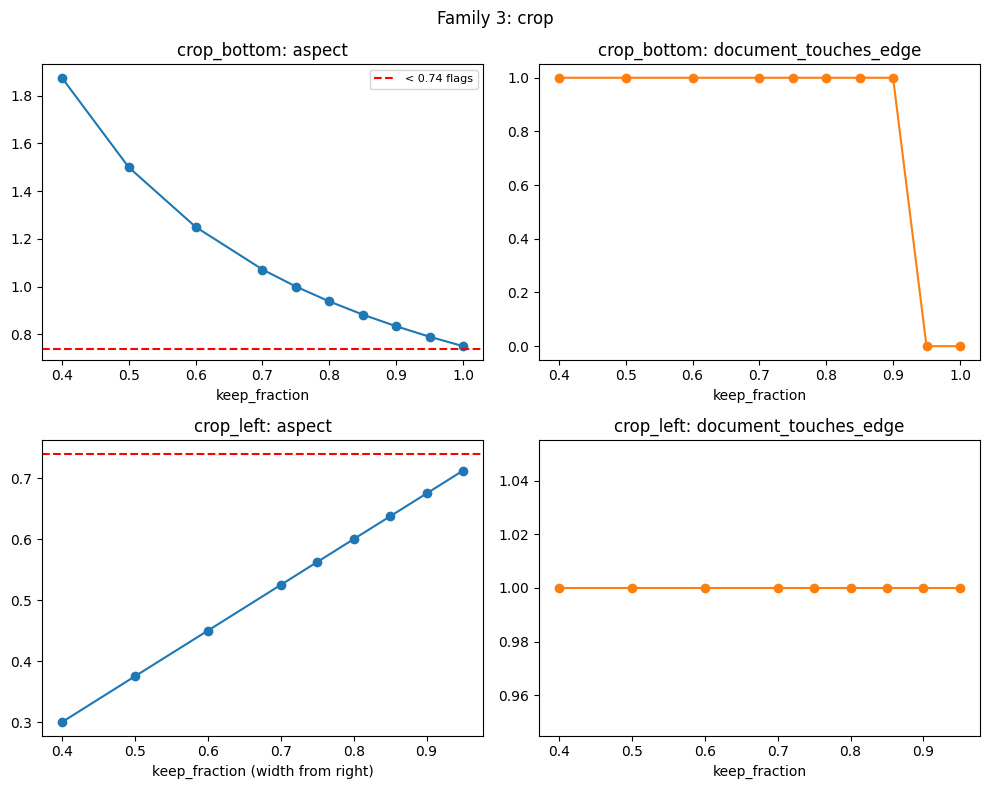

First aspect gate (crop_bottom): None


,keep_fraction,frame_aspect_ratio,document_touches_edge,gate_aspect
51,1.00,0.7500,0,False
52,0.95,0.7895,0,False
53,0.90,0.8335,1,False
54,0.85,0.8824,1,False
55,0.80,0.9376,1,False
56,0.75,1.0000,1,False
57,0.70,1.0715,1,False
58,0.60,1.2501,1,False
59,0.50,1.5000,1,False
60,0.40,1.8757,1,False


In [5]:
CB = df[df["family"] == "crop_bottom"].sort_values("keep_fraction", ascending=False)
CL = df[df["family"] == "crop_left"].sort_values("keep_fraction", ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].plot(CB["keep_fraction"], CB["frame_aspect_ratio"], "o-")
axes[0, 0].axhline(THR_ASPECT, color="r", ls="--", label=f"< {THR_ASPECT} flags")
axes[0, 0].set_title("crop_bottom: aspect")
axes[0, 0].set_xlabel("keep_fraction"); axes[0, 0].legend(fontsize=8)
axes[0, 1].plot(CB["keep_fraction"], CB["document_touches_edge"], "o-", color="C1")
axes[0, 1].set_title("crop_bottom: document_touches_edge")
axes[0, 1].set_xlabel("keep_fraction")
axes[1, 0].plot(CL["keep_fraction"], CL["frame_aspect_ratio"], "o-")
axes[1, 0].axhline(THR_ASPECT, color="r", ls="--")
axes[1, 0].set_title("crop_left: aspect")
axes[1, 0].set_xlabel("keep_fraction (width from right)")
axes[1, 1].plot(CL["keep_fraction"], CL["document_touches_edge"], "o-", color="C1")
axes[1, 1].set_title("crop_left: document_touches_edge")
axes[1, 1].set_xlabel("keep_fraction")
fig.suptitle("Family 3: crop")
fig.tight_layout()
plt.show()

print(
    "First aspect gate (crop_bottom):",
    first_crossing(CB, "keep_fraction", "gate_aspect", order="desc"),
)
CB[["keep_fraction", "frame_aspect_ratio", "document_touches_edge", "gate_aspect"]]

## Family 4 — blur (negative control for four rules)
Sharpness (Laplacian) should drop; four-rule `any_gate` should stay false for mild blur. Motion blur is confounded with synthetic edges — treat as exploratory.

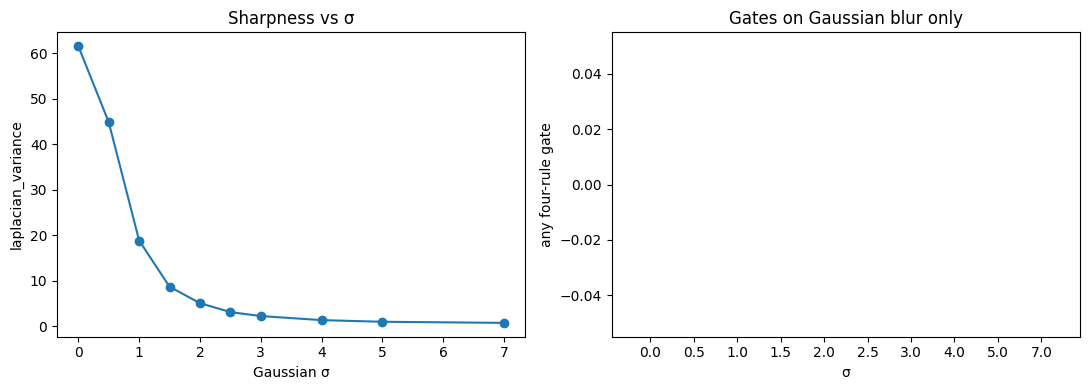

σ ≤ 2.5: any_gate count = 0 / 6
σ ≤ 3.0: any_gate count = 0 / 7
σ ≤ 7.0: any_gate count = 0 / 10


,sigma,laplacian_variance,histogram_entropy,any_gate
70,0.0,61.581975,4.529296,False
71,0.5,44.862352,4.526622,False
72,1.0,18.824500,4.509853,False
73,1.5,8.662004,4.489613,False
74,2.0,5.050703,4.482680,False
75,2.5,3.087118,4.483162,False
76,3.0,2.213387,4.492523,False
77,4.0,1.315451,4.501181,False
78,5.0,0.954232,4.506713,False
79,7.0,0.708872,4.514496,False


In [6]:
G = df[df["family"] == "blur_gaussian"].sort_values("sigma")
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(G["sigma"], G["laplacian_variance"], "o-")
axes[0].set_xlabel("Gaussian σ"); axes[0].set_ylabel("laplacian_variance"); axes[0].set_title("Sharpness vs σ")
axes[1].bar(range(len(G)), G["any_gate"].astype(int), tick_label=[f"{s:.1f}" for s in G["sigma"]])
axes[1].set_xlabel("σ"); axes[1].set_ylabel("any four-rule gate"); axes[1].set_title("Gates on Gaussian blur only")
fig.tight_layout(); plt.show()

for cap in (2.5, 3.0, 7.0):
    sub = G[G["sigma"] <= cap]
    n = sub["any_gate"].sum()
    print(f"σ ≤ {cap}: any_gate count = {int(n)} / {len(sub)}")
G[["sigma", "laplacian_variance", "histogram_entropy", "any_gate"]]

/var/folders/bq/3781k3k11b9b5cgw79z5d7rr0000gn/T/ipykernel_18290/3447471460.py:8: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(sub["motion_length"], sub["laplacian_variance"], "o-", label=f"angle={int(ang)}", linestyle=sty)


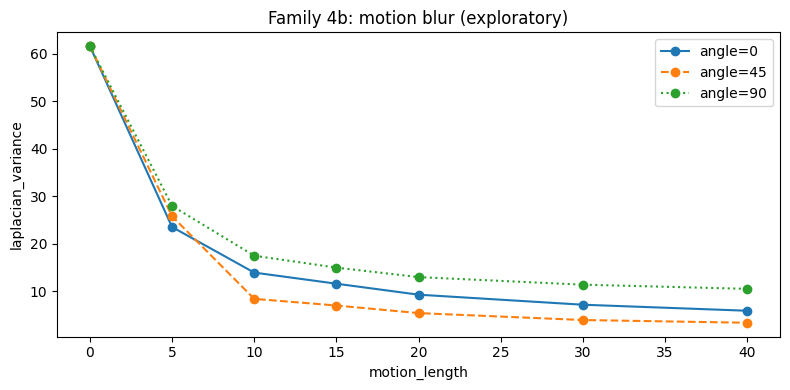

any_gate on motion: 0 / 21


In [7]:
M = df[df["family"] == "blur_motion"]
if len(M) == 0:
    print("No motion blur rows (scipy or validator skipped).")
else:
    plt.figure(figsize=(8, 4))
    for ang, sty in zip(sorted(M["motion_angle"].unique()), ["-", "--", ":"]):
        sub = M[M["motion_angle"] == ang].sort_values("motion_length")
        plt.plot(sub["motion_length"], sub["laplacian_variance"], "o-", label=f"angle={int(ang)}", linestyle=sty)
    plt.xlabel("motion_length"); plt.ylabel("laplacian_variance"); plt.legend(); plt.title("Family 4b: motion blur (exploratory)")
    plt.tight_layout(); plt.show()
    print("any_gate on motion:", M["any_gate"].sum(), "/", len(M))
    M.pivot_table(index="motion_length", columns="motion_angle", values="any_gate", aggfunc="max")

## Gate mix by family
Which of the four rules fire in each experiment arm?

In [8]:
if "df_test" not in globals():
    if "df" in globals():
        df_test = df
    else:
        raise NameError(
            "df_test is not defined. Run the first 'Load data' code cell to load variant_attributes.csv and set df_test."
        )
by = df_test.groupby("family", dropna=False)[gate_cols].sum().astype(int)
by["any_gate_rows"] = df_test.groupby("family")["any_gate"].sum().astype(int)
by["n_rows"] = df_test.groupby("family").size()
try:
    from IPython.display import display
    display(by)
except ImportError:
    print(by)

for name in ("summary.md", "false_positive_report.txt", "base_gate_check.txt"):
    p = RESULT / name
    if p.is_file():
        text = p.read_text(encoding="utf-8")
        clip = text[:3000] + ("\n… [truncated]" if len(text) > 3000 else "")
        print(f"\n--- {name} ---\n{clip}")


,gate_entropy,gate_rotation,gate_aspect,gate_white,any_gate_rows,n_rows
family,,,,,,
blur_gaussian,0,0,0,0,0,10
blur_motion,0,0,0,0,0,21
crop_bottom,0,0,0,0,0,10
crop_left,0,0,9,0,9,9
distance,0,0,0,15,15,27
rotation,0,10,0,0,10,24



--- summary.md ---
# Synthetic threshold validation

Base image passed gate self-check: **True**

Thresholds:
- `histogram_entropy` ≥ 5.15  → flag
- `|rotation_angle|` > 25.0  → flag
- `frame_aspect_ratio` < 0.74  → flag
- `white_region_ratio` < 0.1  → flag

## Summary table

| Family | Parameter | Threshold | First fire (approx.) | Notes |
|--------|-----------|-----------|----------------------|-------|
| distance | scale | entropy≥5.15 | see below | per background in detail below |
| distance | scale | white<0.1 | see below | per background |
| rotation | input_angle_deg | |rot|>25.0 | -30.0 | Hough vs applied angle |
| crop_bottom | keep_fraction | aspect<0.74 | — | w/h after bottom crop |
| blur_gaussian | sigma | none (blur) | — | should stay false — negative control |

## D01 crop & deadline (visual estimate)
The deadline / response box is typically in the **lower half** of a full-page notice. `crop_bottom` with `keep_fraction` below ~**0.55–0.65** risks removing fields that si

## Part 2 — Pipeline and performance validation

*The first markdown cell outlines Parts 1 and 2.* Below: characterizer API, optional Ollama D01 run, and blur-style metrics.


## `real_photo_characterizer` API

- **`extract_attributes(path)`** — Re-run the same OpenCV pipeline as the validator on a sample variant and compare to the CSV row (sanity check).
- **`analyze(df)`** — Expects a `label` column (`"pass"` / `"fail"`). We set **pass = no four-rule gate**, **fail = any gate**, matching a coarse pass/fail view of the pre-screener. Returns Cohen ranking, LOO logistic accuracy, `coef_df`, and **`find_best_threshold`**-style rules for the top attribute and for Laplacian.
- **`find_best_threshold(df, attribute)`** — Exploratory single-metric pass rule; we also call it for the four pre-screen metrics.


In [9]:
import sys
if str(_EV) not in sys.path:
    sys.path.insert(0, str(_EV))

from real_photo_characterizer import (
    ATTRIBUTE_COLS,
    analyze,
    extract_attributes,
    find_best_threshold,
)


def _resolve_variant_path(rel: str) -> Path:
    rel = str(rel).strip()
    p = Path(rel)
    if p.is_file():
        return p.resolve()
    for root in (_EV.parent.parent, _EV, Path.cwd(), Path.cwd() / "research" / "eval"):
        try:
            cand = (root / rel).resolve()
        except (OSError, ValueError):
            continue
        if cand.is_file():
            return cand
    raise FileNotFoundError(
        f"Could not find image on disk for path={rel!r}. "
        f"Set cwd to repo root or research/eval."
    )

# --- 1) extract_attributes vs stored CSV (first row)
row0 = df.iloc[0]
path0 = _resolve_variant_path(str(row0["path"]))
a0 = extract_attributes(path0)
check_cols = [c for c in ("histogram_entropy", "rotation_angle", "frame_aspect_ratio", "white_region_ratio", "laplacian_variance") if c in row0.index and c in a0]
mism = []
for c in check_cols:
    v_csv, v_new = float(row0[c]), float(a0[c])
    if not np.isclose(v_csv, v_new, rtol=0, atol=1e-3 if c != "rotation_angle" else 0.5):
        mism.append((c, v_csv, v_new))
if mism:
    print("Mismatches (tolerance may be OK for Hough angle):", mism)
else:
    print(f"extract_attributes({path0.name}) matches CSV for {check_cols}.")

# optional: second row (different family)
if len(df) > 1:
    r1 = df.iloc[len(df) // 2]
    p1 = _resolve_variant_path(str(r1["path"]))
    a1 = extract_attributes(p1)
    if not np.isclose(float(r1["laplacian_variance"]), float(a1["laplacian_variance"]), rtol=0.01, atol=0.1):
        print("Mid-row Laplacian check:", r1["laplacian_variance"], a1["laplacian_variance"])
    else:
        print("Mid-row re-extract Laplacian OK:", p1.name)

# --- 2) analyze() with synthetic pass/fail labels
if "df_test" not in globals():
    if "df" in globals():
        df_test = df
    else:
        raise NameError(
            "df_test is not defined. Run the first 'Load data' code cell to load variant_attributes.csv and set df_test."
        )
df_labeled = df_test.copy()
df_labeled["label"] = np.where(~df_labeled["any_gate"], "pass", "fail")

if df_labeled["label"].nunique() < 2:
    print("analyze() skipped: need both pass and fail rows (vary validator families/thresholds).")
else:
    char_out = analyze(df_labeled)
    print(
        "n_pass=", char_out["n_pass"],
        "n_fail=",
        char_out["n_fail"],
        "loo_accuracy=",
        round(char_out["loo_accuracy"], 4),
    )
    if len(char_out["ranking"]):
        try:
            from IPython.display import display
            display(char_out["ranking"].head(20))
        except ImportError:
            print(char_out["ranking"].head(20))
    if len(char_out["coef_df"]):
        try:
            display(char_out["coef_df"].head(20))
        except ImportError:
            print(char_out["coef_df"].head(20))
    print("best_rule (top |d| attr):", char_out["best_rule"])
    print("current_detector (laplacian_variance):", char_out["current_detector"])

# --- 3) find_best_threshold for the four pre-screen metrics (exploratory)
print("\\nfind_best_threshold (label = pass if no four-rule gate):")
for attr in (
    "histogram_entropy",
    "rotation_angle",
    "frame_aspect_ratio",
    "white_region_ratio",
):
    r = find_best_threshold(df_labeled, attr)
    print(f"  {attr}: {r}")


extract_attributes(distance_solid_gray_1.00.jpg) matches CSV for ['histogram_entropy', 'rotation_angle', 'frame_aspect_ratio', 'white_region_ratio', 'laplacian_variance'].
Mid-row re-extract Laplacian OK: rotation_+090deg.jpg
n_pass= 67 n_fail= 34 loo_accuracy= 0.9406


,attribute,pass_mean,fail_mean,cohens_d,p_value,significant
12,white_region_ratio,0.420,0.252,1.123,0.0000,True
5,luminance_std,58.251,42.662,1.063,0.0000,True
8,rms_contrast,0.228,0.167,1.063,0.0000,True
4,mean_luminance,151.373,159.263,0.951,0.0000,True
6,histogram_entropy,4.324,3.311,0.827,0.0006,True
25,document_center_offset,0.028,0.017,0.810,0.0169,True
23,document_aspect_ratio,0.951,0.813,0.792,0.0000,True
17,quadrant_luminance_variance,104.645,256.531,0.713,0.7220,False
24,frame_aspect_ratio,0.801,0.694,0.704,0.0000,True
21,gradient_direction_entropy,4.991,5.117,0.680,0.0029,True


,attribute,coefficient,abs_coefficient
22,document_touches_edge,-1.189,1.189
16,shadow_ratio,1.053,1.053
17,quadrant_luminance_variance,-0.991,0.991
25,document_center_offset,0.886,0.886
19,quadrant_luminance_ratio,0.818,0.818
24,frame_aspect_ratio,0.655,0.655
13,document_coverage_ratio,-0.655,0.655
6,histogram_entropy,0.636,0.636
23,document_aspect_ratio,0.623,0.623
8,rms_contrast,0.623,0.623


best_rule (top |d| attr): {'attribute': 'white_region_ratio', 'threshold': 0.42, 'direction': 'above', 'accuracy': 0.842, 'n_correct': 85, 'n_total': 101, 'rule': 'pass if white_region_ratio ≥ 0.42'}
current_detector (laplacian_variance): {'attribute': 'laplacian_variance', 'threshold': 80.68, 'direction': 'below', 'accuracy': 0.762, 'n_correct': 77, 'n_total': 101, 'rule': 'pass if laplacian_variance < 80.68'}
\nfind_best_threshold (label = pass if no four-rule gate):
  histogram_entropy: {'attribute': 'histogram_entropy', 'threshold': 1.98, 'direction': 'above', 'accuracy': 0.762, 'n_correct': 77, 'n_total': 101, 'rule': 'pass if histogram_entropy ≥ 1.98'}
  rotation_angle: {'attribute': 'rotation_angle', 'threshold': -5.0, 'direction': 'above', 'accuracy': 0.683, 'n_correct': 69, 'n_total': 101, 'rule': 'pass if rotation_angle ≥ -5.0'}
  frame_aspect_ratio: {'attribute': 'frame_aspect_ratio', 'threshold': 0.75, 'direction': 'above', 'accuracy': 0.752, 'n_correct': 76, 'n_total': 101

## D01 LLM extraction (same as `real_photo_characterizer` inference)

Calls **`run_extraction()`** from [`real_photo_characterizer.py`](./real_photo_characterizer.py): resizes for Ollama, **`call_ollama`** with the D01 **semantic** prompt, **`parse_with_retry` → `score_against_ground_truth`**, same pipeline as a full run (the script’s outer loop is just `for photo in photos` + CSV).

- **Default: no calls.** Set **`SYNTHETIC_LLM_MAX`** to process the first *N* rows of **`df_test`** (the family-scoped table from the [Test scope](#Test-scope-environment) `SYNTHETIC_FAMILIES` filter, or the full set if unset). You can set **`IN_NOTEBOOK_LLM=1`** and **`SYNTHETIC_LLM_N`** for a small batch from the environment.
- **Ollama temperature:** set **`SYNTHETIC_LLM_TEMPERATURE`** (or alias **`SYNTHETIC_D01_TEMPERATURE`**) to a float; default `0`. Other knobs: `SYNTHETIC_LLM_RUNS`, `SYNTHETIC_LLM_OLLAMA_MAX_LONG_EDGE`, `SYNTHETIC_LLM_OLLAMA_TIMEOUT`.
- **Requires** Ollama with a vision model at `http://127.0.0.1:11434`.
- Writes **`synthetic_eval_runs.csv`** next to `variant_attributes.csv` when any run completes (same shape as `eval_runs.csv`, plus `synth_family` and `any_gate` for joins).


In [12]:
import os
import time

if "df_test" not in globals():
    if "df" in globals():
        df_test = df
    else:
        raise NameError(
            "df_test is not defined. Run the first 'Load data' code cell to load variant_attributes.csv and set df_test."
        )

os.environ["SYNTHETIC_LLM_MAX"] = "100"
os.environ["SYNTHETIC_LLM_RUNS"] = "1"
os.environ["SYNTHETIC_FAMILIES"] = "blur"
os.environ["SYNTHETIC_LLM_TEMPERATURE"] = "0"

if str(_EV) not in sys.path:
    sys.path.insert(0, str(_EV))

# Safe if the characterizer cell above was not run
try:
    _resolve_variant_path
except NameError:
    def _resolve_variant_path(rel: str) -> Path:
        rel = str(rel).strip()
        p = Path(rel)
        if p.is_file():
            return p.resolve()
        for root in (_EV.parent.parent, _EV, Path.cwd(), Path.cwd() / "research" / "eval"):
            try:
                cand = (root / rel).resolve()
            except (OSError, ValueError):
                continue
            if cand.is_file():
                return cand
        raise FileNotFoundError(f"Could not find image: {rel!r}")

from real_photo_characterizer import (
    run_extraction,
    ollama_available,
    flatten_extraction_run,
)
from runner import load_ground_truth

# Max variant JPEGs to send (0 = skip). Primary knob: env SYNTHETIC_LLM_MAX
_llm_max = int(os.environ.get("SYNTHETIC_LLM_MAX", "0"))
if os.environ.get("IN_NOTEBOOK_LLM", "").strip().lower() in ("1", "true", "yes"):
    _llm_max = max(_llm_max, int(os.environ.get("SYNTHETIC_LLM_N", "3")))

_runs = int(os.environ.get("SYNTHETIC_LLM_RUNS", "1"))
_cooldown = float(os.environ.get("SYNTHETIC_LLM_COOLDOWN", "2.0"))
_break = float(os.environ.get("SYNTHETIC_LLM_PHOTO_BREAK", "5.0"))
_olledge = int(os.environ.get("SYNTHETIC_LLM_OLLAMA_MAX_LONG_EDGE", "1024"))
_oltimeout = float(os.environ.get("SYNTHETIC_LLM_OLLAMA_TIMEOUT", "600"))
_oltemp = float(
    os.environ.get(
        "SYNTHETIC_LLM_TEMPERATURE",
        os.environ.get("SYNTHETIC_D01_TEMPERATURE", "0"),
    )
)

if _llm_max <= 0:
    print(
        "LLM: skipped. Set e.g. export SYNTHETIC_LLM_MAX=5 to run 5 variants, "
        "or IN_NOTEBOOK_LLM=1 with SYNTHETIC_LLM_N=3."
    )
elif not ollama_available():
    print("LLM: skipped — Ollama not at http://127.0.0.1:11434 (ollama serve).")
else:
    _gt = load_ground_truth()
    out_rows: list[dict] = []
    n_sent = 0
    for _, row in df_test.iterrows():
        if n_sent >= _llm_max:
            break
        try:
            path_im = _resolve_variant_path(str(row["path"]))
        except FileNotFoundError as e:
            print("skip path:", e)
            continue
        print(
            f"LLM {n_sent + 1}/{_llm_max}: {path_im.name}  family={row.get('family')!r}",
            flush=True,
        )
        try:
            ex = run_extraction(
                path_im,
                "ollama",
                None,
                _gt,
                n_runs=_runs,
                cooldown=_cooldown,
                ollama_max_long_edge=_olledge,
                ollama_timeout_s=_oltimeout,
                ollama_temperature=_oltemp,
            )
        except Exception as e:
            print("  run_extraction error:", repr(e))
            continue
        for item in ex:
            flat = flatten_extraction_run(path_im.name, item)
            flat["synth_family"] = row.get("family", "")
            flat["any_gate"] = bool(row.get("any_gate", False))
            out_rows.append(flat)
        if ex:
            pr = sum(1 for r in ex if r.get("critical_deadline_exact")) / len(ex)
            if _runs >= 2:
                lbl = "pass" if pr >= (2.0 / 3.0) else "fail"
            else:
                lbl = "pass" if ex[0].get("critical_deadline_exact") else "fail"
            print(f"  deadline-exact rate={pr:.2f}  2/3-style label={lbl}", flush=True)
        n_sent += 1
        if n_sent < _llm_max and _break > 0:
            time.sleep(_break)

    if out_rows:
        run_df = pd.DataFrame(out_rows)
        out_csv = RESULT / "synthetic_eval_runs.csv"
        out_csv.parent.mkdir(parents=True, exist_ok=True)
        run_df.to_csv(out_csv, index=False)
        print("Wrote", out_csv, "rows=", len(run_df))
        try:
            from IPython.display import display
            display(run_df.head(20))
        except ImportError:
            print(run_df.head(20).to_string())
    else:
        print("No LLM rows written.")


LLM 1/100: distance_solid_gray_1.00.jpg  family='distance'
  Ollama input: distance_solid_gray_1.00.jpg → 768×1024 JPEG (~106 KB, max edge 1024px)
  HTTP POST /api/chat (heartbeat every 15s until response). First run may spend minutes loading the model into memory.
  … still waiting on Ollama (15s elapsed). First vision request often loads a large model; CPU inference is slow.
  … still waiting on Ollama (30s elapsed). First vision request often loads a large model; CPU inference is slow.
  deadline-exact rate=1.00  2/3-style label=pass
LLM 2/100: distance_solid_gray_0.85.jpg  family='distance'
  Ollama input: distance_solid_gray_0.85.jpg → 768×1024 JPEG (~86 KB, max edge 1024px)
  HTTP POST /api/chat (heartbeat every 15s until response). First run may spend minutes loading the model into memory.
  deadline-exact rate=1.00  2/3-style label=pass
LLM 3/100: distance_solid_gray_0.70.jpg  family='distance'
  Ollama input: distance_solid_gray_0.70.jpg → 768×1024 JPEG (~66 KB, max edge 1024p

,filename,run,critical_deadline_exact,notice_date_label,notice_date_score,notice_date_correct_field,response_deadline_label,response_deadline_score,response_deadline_correct_field,requested_category_label,...,caseworker_name_score,caseworker_name_correct_field,case_number_label,case_number_score,case_number_correct_field,recipient_name_label,recipient_name_score,recipient_name_correct_field,synth_family,any_gate
0,distance_solid_gray_1.00.jpg,0,True,exact,2.0,True,exact,2.0,True,format_mismatch,...,2.0,True,exact,2.0,True,exact,2.0,True,distance,False
1,distance_solid_gray_0.85.jpg,0,True,exact,2.0,True,exact,2.0,True,format_mismatch,...,-1.0,False,exact,2.0,True,transcription_error,0.0,True,distance,False
2,distance_solid_gray_0.70.jpg,0,False,hallucinated,-1.0,True,hallucinated,-1.0,True,format_mismatch,...,-1.0,False,transcription_error,0.0,True,partial,1.0,True,distance,False
3,distance_solid_gray_0.55.jpg,0,False,hallucinated,-1.0,True,hallucinated,-1.0,True,format_mismatch,...,0.0,True,unreadable,0.0,True,unreadable,0.0,True,distance,False
4,distance_solid_gray_0.45.jpg,0,False,hallucinated,-1.0,True,hallucinated,-1.0,True,hallucinated,...,0.0,True,unreadable,0.0,True,unreadable,0.0,True,distance,True
5,distance_solid_gray_0.35.jpg,0,False,hallucinated,-1.0,True,hallucinated,-1.0,True,misattribution,...,-1.0,True,hallucinated,-1.0,True,hallucinated,-1.0,True,distance,True
6,distance_solid_gray_0.25.jpg,0,False,unreadable,0.0,True,unreadable,0.0,True,unreadable,...,0.0,True,unreadable,0.0,True,unreadable,0.0,True,distance,True
7,distance_solid_gray_0.20.jpg,0,False,unreadable,0.0,True,unreadable,0.0,True,unreadable,...,0.0,True,unreadable,0.0,True,unreadable,0.0,True,distance,True
8,distance_solid_gray_0.15.jpg,0,False,hallucinated,-1.0,True,hallucinated,-1.0,True,hallucinated,...,0.0,True,unreadable,0.0,True,unreadable,0.0,True,distance,True
9,distance_desk_texture_1.00.jpg,0,True,exact,2.0,True,exact,2.0,True,format_mismatch,...,2.0,True,exact,2.0,True,exact,2.0,True,distance,False


## Eval: metrics (same spirit as `blur_testing.ipynb` §1 & §8)

- **Describe + Pearson correlation** over **`df_test`** rows (see `SYNTHETIC_FAMILIES`). Correlations *mix* included families—use for redundancy checks, not causal claims.
- **Effect sizes (Cohen’s d + Mann–Whitney)** comparing rows with **no** four-rule gate vs **any** gate fired (like pass vs fail on real photos). Synthetic labels are *deterministic* for many arms; still useful to see which metrics move with “bad” pixels.
- **Logistic regression (exploratory):** standardized metrics → P(`any_gate`). In-sample and **leave-one-out** probabilities, same pattern as the blur notebook.

In [ ]:
import sys
if str(_EV) not in sys.path:
    sys.path.insert(0, str(_EV))
from real_photo_characterizer import ATTRIBUTE_COLS as METRIC_COLS

if "df_test" not in globals():
    if "df" in globals():
        df_test = df
    else:
        raise NameError(
            "df_test is not defined. Run the first 'Load data' code cell to load variant_attributes.csv and set df_test."
        )
metric_cols = [c for c in METRIC_COLS if c in df.columns]
if len(df_test) < 2:
    raise ValueError(
    "df_test has <2 rows; widen SYNTHETIC_FAMILIES or use all."
)

miss = [c for c in METRIC_COLS if c not in df.columns]
if miss:
    print("Note: missing columns (skipped):", miss)

summary = df_test[metric_cols].describe().T
try:
    from IPython.display import display
    display(summary.round(3))
except ImportError:
    print(summary.round(3))

corr = df_test[metric_cols].corr(method="pearson")
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(metric_cols)))
ax.set_yticks(range(len(metric_cols)))
ax.set_xticklabels(metric_cols, rotation=45, ha="right")
ax.set_yticklabels(metric_cols)
ax.set_title("Pearson r — all synthetic variants (mixed families)")
for i in range(len(metric_cols)):
    for j in range(len(metric_cols)):
        v = corr.values[i, j]
        if not np.isnan(v) and abs(v) >= 0.35:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=5, color="black")
plt.colorbar(im, ax=ax, fraction=0.046, label="r")
plt.tight_layout()
plt.show()

# Point-biserial: metric vs any_gate (0/1)
ag = df_test["any_gate"].astype(int)
pb = df_test[metric_cols].corrwith(ag)
top = pb.reindex(pb.abs().sort_values(ascending=False).index).head(12)
print("Top |r| with any_gate (point-biserial / Pearson):")
print(top.round(3).to_string())


In [ ]:
from scipy import stats as scipy_stats

def cohen_mann_table(
    frame: pd.DataFrame,
    mask_neg: pd.Series,
    mask_pos: pd.Series,
    label_neg: str,
    label_pos: str,
) -> pd.DataFrame:
    rows = []
    for col in metric_cols:
        a = frame.loc[mask_neg, col].dropna()
        b = frame.loc[mask_pos, col].dropna()
        if len(a) < 2 or len(b) < 2:
            continue
        pooled = np.sqrt((a.std() ** 2 + b.std() ** 2) / 2)
        d = (a.mean() - b.mean()) / (pooled + 1e-10)
        try:
            _, p = scipy_stats.mannwhitneyu(a, b, alternative="two-sided")
        except ValueError:
            continue
        row = {
            "attribute": col,
        }
        row[label_neg + "_mean"] = round(float(a.mean()), 3)
        row[label_pos + "_mean"] = round(float(b.mean()), 3)
        row["cohens_d"] = round(float(np.abs(d)), 3)
        row["p_value"] = round(float(p), 4)
        row["significant"] = bool(p < 0.05)
        rows.append(row)
    return pd.DataFrame(rows).sort_values("cohens_d", ascending=False)


if "df_test" not in globals():
    if "df" in globals():
        df_test = df
    else:
        raise NameError(
            "df_test is not defined. Run the first 'Load data' code cell to load variant_attributes.csv and set df_test."
        )
ok = ~df_test["any_gate"]
bad = df_test["any_gate"]
rank_any = cohen_mann_table(df_test, ok, bad, "no_gate", "any_gate")
print(f"no_gate: n={ok.sum()} | any_gate: n={bad.sum()}")
try:
    from IPython.display import display
    display(rank_any)
except ImportError:
    print(rank_any)

print("\n--- Per-gate: which metrics differ when that gate alone is considered vs rest? (exploratory) ---")
for gcol in gate_cols:
    pos = df_test[gcol] == True  # noqa: E712
    neg = ~pos
    if pos.sum() < 2 or neg.sum() < 2:
        print(f"{gcol}: skip (need ≥2 in each group)")
        continue
    t = cohen_mann_table(df_test, neg, pos, "gate_off", "gate_on")
    top3 = t.head(3)[["attribute", "cohens_d", "p_value"]]
    print(f"\n{gcol} (n_on={int(pos.sum())}):")
    print(top3.to_string(index=False))


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler

if "df_test" not in globals():
    if "df" in globals():
        df_test = df
    else:
        raise NameError(
            "df_test is not defined. Run the first 'Load data' code cell to load variant_attributes.csv and set df_test."
        )
y = df_test["any_gate"].astype(int).to_numpy()
cols = [c for c in metric_cols if c in df.columns]
if y.min() == y.max() or len(cols) < 2:
    print("Skip logistic: need both classes and ≥2 features.")
else:
    X = df_test[cols].fillna(0.0).to_numpy()
    sc = StandardScaler()
    Xs = sc.fit_transform(X)
    m = LogisticRegression(
        max_iter=8000,
        C=0.5,
        class_weight="balanced",
        random_state=0,
    )
    m.fit(Xs, y)
    p_in = m.predict_proba(Xs)[:, 1]
    yhat = m.predict(Xs)

    loo = LeaveOneOut()
    p_loo = np.full(len(y), np.nan, dtype=float)
    for tr, te in loo.split(Xs):
        yt, ye = y[tr], y[te]
        if np.all(yt == 0) or np.all(yt == 1):
            p_loo[te[0]] = float(np.mean(yt))
            continue
        mlo = LogisticRegression(
            max_iter=8000, C=0.5, class_weight="balanced", random_state=0
        )
        mlo.fit(Xs[tr], yt)
        p_loo[te[0]] = float(mlo.predict_proba(Xs[te])[0, 1])

    pred = pd.DataFrame(
        {
            "filename": df_test["filename"].values,
            "family": df_test["family"].values,
            "y_any_gate": y,
            "p_any_insample": p_in,
            "p_any_loo": p_loo,
            "y_hat_in": yhat,
            "y_hat_loo": (p_loo >= 0.5).astype(int),
        }
    )
    pclip = pred["p_any_insample"].to_numpy().clip(1e-6, 1.0 - 1e-6)
    _ll = log_loss(y, pclip, labels=[0, 1])
    print(f"In-sample log loss: {_ll:.4f}")
    n_err = (pred["y_hat_loo"] != y).sum()
    print(f"LOO hard error: {n_err}/{len(y)}  |  baseline always-majority: {max(y.mean(), 1-y.mean()):.3f}")

    coef_df = (
        pd.DataFrame({"attribute": cols, "coef": m.coef_.ravel()})
        .assign(abs_coef=lambda x: np.abs(x["coef"]))
        .sort_values("abs_coef", ascending=False)
    )
    print(f"Fitted LogisticRegression (C=0.5, balanced, n={len(y)}), intercept: {m.intercept_[0]:.4f}")
    try:
        from IPython.display import display
        display(coef_df.drop(columns="abs_coef").round(4))
        display(pred.sort_values("p_any_loo", ascending=False).round(4).head(20))
    except ImportError:
        print(coef_df)
        print(pred.sort_values("p_any_loo", ascending=False).head(20))

    REG_SYNTH = {"model": m, "scaler": sc, "feature_cols": cols, "y": y}
    print("`REG_SYNTH` dict holds fitted model + scaler for reuse.")
